# Positron Angle Regression Training (Unified Config Pipeline)

This notebook trains/evaluates/exports the positron-angle regressor with the unified `training_pipeline` using aligned upstream prediction shards.

## 1) Environment Setup

In [1]:
from pathlib import Path

from pioneerml.evaluation.plots.loss import LossCurvesPlot
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.pipeline.pipelines.training import training_pipeline

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## 2) Select and Align Input Files

Positron-angle training requires aligned files for:
- main event parquet
- group-classifier predictions
- group-splitter predictions
- endpoint-regressor predictions
- event-splitter predictions
- pion-stop predictions

In [2]:
def _pick_pred(pred_dir: Path, main_path: Path) -> Path | None:
    candidates = [
        pred_dir / f"{main_path.stem}_preds.parquet",
        pred_dir / f"{main_path.stem}_preds_latest.parquet",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

data_dir = Path(PROJECT_ROOT) / "data"
main_paths = sorted(data_dir.glob("ml_output_*.parquet"))

# Optional: use fewer shards for quick runs
main_paths = main_paths[:1]

group_probs_dir = data_dir / "group_classifier"
group_splitter_dir = data_dir / "group_splitter"
endpoint_dir = data_dir / "endpoint_regressor"
event_splitter_dir = data_dir / "event_splitter"
pion_stop_dir = data_dir / "pion_stop_regression"

aligned = []
for main in main_paths:
    gp = _pick_pred(group_probs_dir, main)
    gs = _pick_pred(group_splitter_dir, main)
    ep = _pick_pred(endpoint_dir, main)
    es = _pick_pred(event_splitter_dir, main)
    ps = _pick_pred(pion_stop_dir, main)

    if not (gp and gs and ep and es and ps):
        missing = []
        if gp is None:
            missing.append("group_classifier")
        if gs is None:
            missing.append("group_splitter")
        if ep is None:
            missing.append("endpoint_regressor")
        if es is None:
            missing.append("event_splitter")
        if ps is None:
            missing.append("pion_stop_regression")
        raise RuntimeError(f"Missing aligned predictions for {main.name}: {', '.join(missing)}")

    aligned.append((main, gp, gs, ep, es, ps))

if not aligned:
    raise RuntimeError("No aligned input shards found for positron-angle training.")

parquet_paths = [str(m.resolve()) for (m, _, _, _, _, _) in aligned]
group_probs_parquet_paths = [str(gp.resolve()) for (_, gp, _, _, _, _) in aligned]
group_splitter_parquet_paths = [str(gs.resolve()) for (_, _, gs, _, _, _) in aligned]
endpoint_parquet_paths = [str(ep.resolve()) for (_, _, _, ep, _, _) in aligned]
event_splitter_parquet_paths = [str(es.resolve()) for (_, _, _, _, es, _) in aligned]
pion_stop_parquet_paths = [str(ps.resolve()) for (_, _, _, _, _, ps) in aligned]

print(f"Using {len(parquet_paths)} aligned shard(s).")


Using 1 aligned shard(s).


## 3) Reusable Config Helpers

In [3]:
from pioneerml.plugin.runtime import ensure_plugins_loaded
ensure_plugins_loaded()

from pioneerml_base_plugin.positron_angle.pipeline import load_config
from pioneerml_base_plugin.utils.config_loader import with_export_output, with_loader_sources


## 4) Build Step Config Blocks

HPO search-space keys are routed automatically:
- architecture keys (`hidden`, `heads`, `layers`, `dropout`) update `architecture.config`
- module keys (`lr`, `weight_decay`) update `module.config`
- runtime keys (`batch_size`) are applied to loader defaults.

In [4]:
pipeline_config = load_config()["training"]
optional_sources_by_name = {
    "group_probs": group_probs_parquet_paths,
    "group_splitter": group_splitter_parquet_paths,
    "endpoint": endpoint_parquet_paths,
    "event_splitter": event_splitter_parquet_paths,
    "pion_stop": pion_stop_parquet_paths,
}
pipeline_config = with_loader_sources(
    pipeline_config,
    main_sources=parquet_paths,
    optional_sources_by_name=optional_sources_by_name,
)
pipeline_config = with_export_output(
    pipeline_config,
    export_dir=str(Path(PROJECT_ROOT) / "trained_models" / "positron_angle_regression"),
    filename_prefix="positron_angle",
)


## 5) Assemble `pipeline_config` and Run

In [5]:
run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=pipeline_config,
)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-03-26 01:47:32,625] A new study created in RDB with name: positron_angle_hpo


[tune_model] GPU available: True (cuda), used: True
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set torch.set_float32_matmul_precision('medium' | 'high') which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
[tune_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PositronAngleModel  │  867 K │ train │     0 │
│ 1 │ loss_fn │ QuantileAngularLoss │      0 │ train │     0 │
└───┴─────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 867 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 867 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 78                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Step tune_model has finished in 21.837s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PositronAngleModel  │  1.6 M │ train │     0 │
│ 1 │ loss_fn │ QuantileAngularLoss │      0 │ train │     0 │
└───┴─────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] No materializer is registered for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'>, so the default Pickle materializer was used. Pickle is not production ready and should only be used for prototyping as the artifacts cannot be loaded when running with a different Python version. Please consider implementing a custom materializer for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'> according to the instructions at https://docs.zenml.io/concepts/artifacts/materializers
Step train_model has finished in 11.437s.
Step evaluate_model has started.
Step evaluate_model has finished in 1.145s.
Step export_model has started.
Step export_model has finished in 1.190s.
Pipeline run has finished in 40.339s.


## 6) Load Step Outputs and Inspect Results

hpo_params: {'study_name': 'positron_angle_hpo', 'storage': 'sqlite:////workspace/.optuna/positron_angle_hpo.db', 'best_params': {'batch_size_exp': 5, 'lr': 0.006323742665650195, 'weight_decay': 0.0004083829087700182, 'hidden': 320, 'heads': 2, 'layers': 1, 'dropout': 0.2999461260342101, 'batch_size': 32}}
metrics (summary): {'loss': 0.9303772817423315, 'mae': 81706.28645833333, 'train_loss_history_total_points': 6, 'val_loss_history_total_points': 7, 'loss_curves_path': 'artifacts/validation_plots/positron_angle_regressor/loss_curves.png', 'loss_plot_path': 'artifacts/validation_plots/positron_angle_regressor/loss_curves.png'}
export: {'torchscript_path': '/workspace/trained_models/positron_angle_regression/positron_angle_20260326_014810_torchscript.pt', 'metadata_path': '/workspace/trained_models/positron_angle_regression/positron_angle_20260326_014810_meta.json', 'export_type': 'script', 'exporter_type': 'torchscript'}


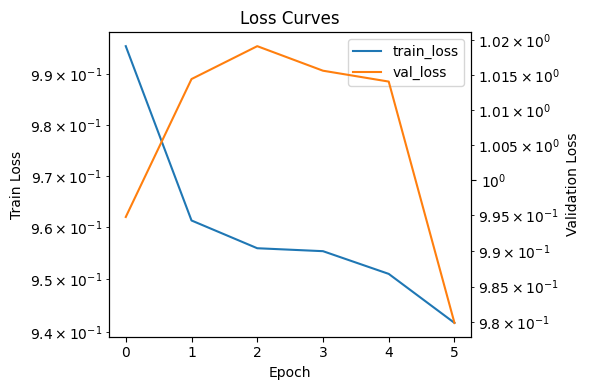

In [6]:
hpo_output = load_step_output(run, "tune_model")
train_output = load_step_output(run, "train_model")
evaluate_output = load_step_output(run, "evaluate_model")
export_output = load_step_output(run, "export_model")

hpo_params = hpo_output.get("hpo_params") if isinstance(hpo_output, dict) else hpo_output
trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output

summary = dict(metrics or {})
summary.pop("train_loss_history", None)
summary.pop("val_loss_history", None)

print("hpo_params:", hpo_params)
print("metrics (summary):", summary)
print("export:", export_output)

if trained_module is None:
    raise RuntimeError("No trained module loaded from pipeline run.")

LossCurvesPlot().render(
    trained_module,
    val_accuracy=(metrics.get("accuracy") if isinstance(metrics, dict) else None),
    show=True,
)
